# Tarea 3 --- IELE756

**Team members:** Felipe Velásquez, Matías Moraga

**Comunas:** El Bosque, Lo Espejo, Isla de Maipo y Pirque

**Fecha:** 03/05/2026

# **Part 0: Building the Analytical Table**

0.1 Class-pooled master table


In [9]:
import pandas as pd
import glob
import os
import zipfile
import re
import numpy as np

# 1. Preparar rutas y extraer archivos
zip_path = '/content/drive/MyDrive/Colab Notebooks/files_export.zip'
extract_path = '/content/shared_data/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# 2. Escaneo de archivos y detección de equipos
all_files = []
for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.endswith(".csv"):
            all_files.append(os.path.join(root, file))

# Obtener IDs de equipos únicos presentes en los nombres de archivo
team_ids = sorted(list(set(re.findall(r'team(\d+)', " ".join([os.path.basename(f) for f in all_files])))))

# Listas para almacenar datos válidos
valid_census_dfs, valid_eno_dfs, valid_grd_dfs = [], [], []
reporte_equipos = []

print(f"Iniciando escaneo de {len(team_ids)} equipos...\n")

for tid in team_ids:
    # Buscar archivos específicos por equipo
    f_census = [f for f in all_files if f"census_team{tid}.csv" in f.lower()]
    f_eno = [f for f in all_files if f"eno_team{tid}.csv" in f.lower()]
    f_grd = [f for f in all_files if f"grd_team{tid}.csv" in f.lower()]

    # CRITERIO DE INCLUSIÓN: El equipo debe tener los 3 archivos
    if f_census and f_eno and f_grd:
        try:
            d_c = pd.read_csv(f_census[0])
            d_e = pd.read_csv(f_eno[0])
            d_g = pd.read_csv(f_grd[0])

            # CRITERIO DE CALIDAD: Los 3 deben tener la columna 'codigo_comuna'
            if all(col in df.columns for df, col in [(d_c,'codigo_comuna'), (d_e,'codigo_comuna'), (d_g,'codigo_comuna')]):
                valid_census_dfs.append(d_c)
                valid_eno_dfs.append(d_e)
                valid_grd_dfs.append(d_g)
                reporte_equipos.append({"Equipo": tid, "Estado": "Aceptado", "Motivo": "Full 3/3 y Schema correcto"})
            else:
                reporte_equipos.append({"Equipo": tid, "Estado": "Excluido", "Motivo": "Falta columna 'codigo_comuna'"})
        except Exception as e:
            reporte_equipos.append({"Equipo": tid, "Estado": "Excluido", "Motivo": f"Error de lectura: {str(e)}"})
    else:
        # Documentamos qué archivos le faltan al equipo
        faltantes = []
        if not f_census: faltantes.append("Censo")
        if not f_eno: faltantes.append("ENO")
        if not f_grd: faltantes.append("GRD")
        reporte_equipos.append({"Equipo": tid, "Estado": "Excluido", "Motivo": f"Incompleto (Falta: {', '.join(faltantes)})"})

# 3. Mostrar resumen de la auditoría de equipos
df_reporte = pd.DataFrame(reporte_equipos)
print("RESUMEN DE AUDITORÍA POR EQUIPO:")
display(df_reporte)

# 4. Crear tablas maestras limpias
census_master = pd.concat(valid_census_dfs, ignore_index=True).drop_duplicates('codigo_comuna')
eno_master = pd.concat(valid_eno_dfs, ignore_index=True).drop_duplicates('codigo_comuna')
grd_master = pd.concat(valid_grd_dfs, ignore_index=True).drop_duplicates('codigo_comuna')

Iniciando escaneo de 19 equipos...

RESUMEN DE AUDITORÍA POR EQUIPO:


,Equipo,Estado,Motivo
0,01,Aceptado,Full 3/3 y Schema correcto
1,02,Aceptado,Full 3/3 y Schema correcto
2,03,Aceptado,Full 3/3 y Schema correcto
3,04,Excluido,Incompleto (Falta: GRD)
4,05,Aceptado,Full 3/3 y Schema correcto
5,06,Aceptado,Full 3/3 y Schema correcto
6,07,Excluido,Falta columna 'codigo_comuna'
7,08,Aceptado,Full 3/3 y Schema correcto
8,09,Aceptado,Full 3/3 y Schema correcto
9,10,Excluido,Incompleto (Falta: GRD)


## **Faltan archivos de varios grupos que no se encontraban en la carpeta**

0.2 Merge on codigo_comuna

In [10]:
# Realizamos un inner merge para asegurar que cada fila tenga la triada completa de datos
analytical_table = census_master.merge(eno_master, on="codigo_comuna", how="inner", suffixes=('', '_eno'))
analytical_table = analytical_table.merge(grd_master, on="codigo_comuna", how="inner", suffixes=('', '_grd'))

# Limpiar columnas redundantes creadas por el merge
cols_to_drop = [c for c in analytical_table.columns if '_eno' in c or '_grd' in c or c == 'COMUNA']
analytical_table = analytical_table.drop(columns=cols_to_drop)

print(f"\nMerge completado exitosamente.")
print(f"Número de comunas finales (N): {len(analytical_table)}")


Merge completado exitosamente.
Número de comunas finales (N): 33


0.3 Derived variables

In [12]:
# A. log_pop_total: Offset para modelos de conteo
analytical_table['log_pop_total'] = np.log(analytical_table['pop_total'])

# B. pct_unemployed: 1 - tasa de empleo (corrigiendo escala si es 0-100)
analytical_table['pct_unemployed'] = (100 - analytical_table['emp_rate_chilean']) / 100

# C. schooling_gap: Brecha de años de estudio (Chilenos - Extranjeros)
analytical_table['schooling_gap'] = analytical_table['mean_schooling_chilean'] - analytical_table['mean_schooling_foreign']

# D. Variable Adicional: 'age_structure' (Edad mediana de la población local)
# Justificación: La edad es un predictor fundamental de hospitalizaciones (GRD).
analytical_table['age_structure'] = analytical_table['median_age_chilean']

# --- LIMPIEZA FINAL DE OUTLIERS DE DATOS MAL FORMADOS ---
# Filtramos comunas con poblaciones imposibles (ej. Santiago con 5k habitantes es un error de algún equipo)
# Usamos un umbral de 5,000 personas para la Región Metropolitana.
analytical_table = analytical_table[analytical_table['pop_total'] > 5000].copy()

# Guardar resultado
output_path = '/content/drive/MyDrive/Colab Notebooks/Tarea 3/output/tarea3_analytical_table.csv'
if not os.path.exists(os.path.dirname(output_path)): os.makedirs(os.path.dirname(output_path))
analytical_table.to_csv(output_path, index=False)

print(f"Parte 0 finalizada. Tabla analítica guardada con N={len(analytical_table)} comunas.")
display(analytical_table[['nombre_comuna', 'pop_total', 'pct_unemployed', 'schooling_gap', 'age_structure']].head())

Parte 0 finalizada. Tabla analítica guardada con N=33 comunas.


,nombre_comuna,pop_total,pct_unemployed,schooling_gap,age_structure
0,La Granja,112022,0.406428,-1.293765,39.0
1,Macul,123800,0.308596,-1.262643,39.0
2,San Ramón,76002,0.396740,-1.395956,40.0
3,La Florida,374836,0.340070,-1.118567,38.0
4,La Reina,103157,0.325000,-0.650000,37.0


## **Part 1: Exploratory Cross-Dataset Analysis**

1.1 Correlation matrix

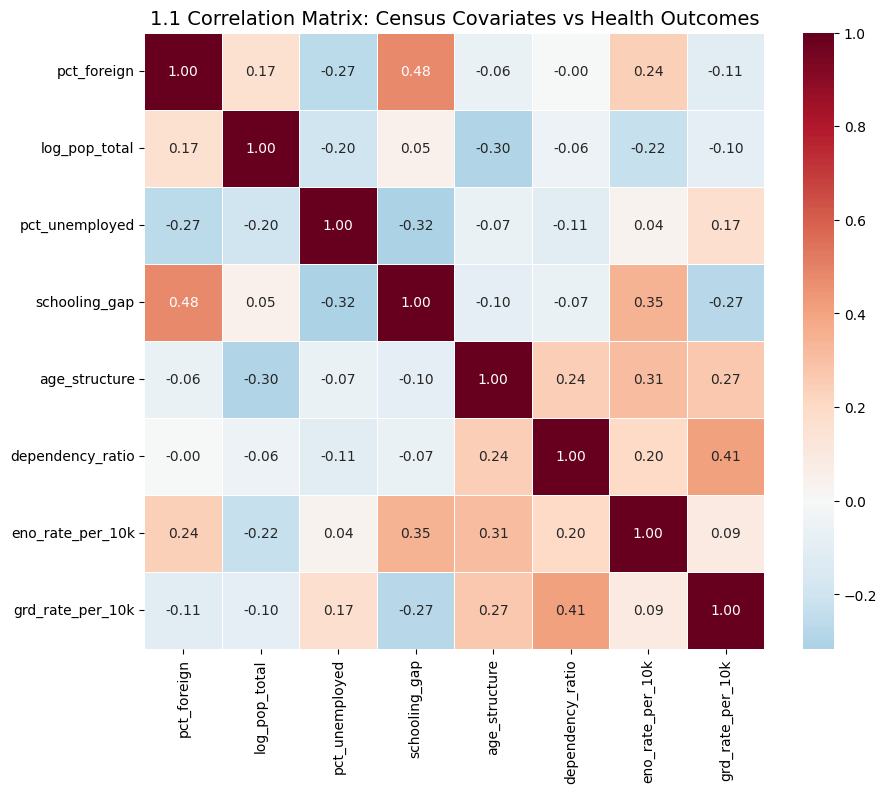

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Seleccionar al menos 6 covariables del censo + los 2 resultados de salud
vars_para_correlacion = [
    'pct_foreign', 'log_pop_total', 'pct_unemployed',
    'schooling_gap', 'age_structure', 'dependency_ratio',
    'eno_rate_per_10k', 'grd_rate_per_10k'
]

# 2. Calcular la matriz
corr_matrix = analytical_table[vars_para_correlacion].corr()

# 3. Visualizar con un Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f", linewidths=0.5)

plt.title("1.1 Correlation Matrix: Census Covariates vs Health Outcomes", fontsize=14)
plt.show()

**Interpretation of the Correlation Matrix**

La matriz de correlación de Pearson revela asociaciones interesantes entre las variables demográficas del Censo y los indicadores de salud a nivel comunal. Las tres asociaciones más significativas son:

1.  **Dependency Ratio y GRD Rate (0.41):** Esta es una de las correlaciones positivas más fuertes. Indica que las comunas con una mayor proporción de población dependiente (menores de 15 y mayores de 65 años) presentan tasas más altas de hospitalización. Esto es biológicamente esperado, ya que los extremos de la vida son los grupos que más demandan servicios asistenciales.
2.  **Schooling Gap y ENO Rate (0.35):** Existe una asociación positiva moderada entre la brecha educacional (escolaridad chilena menos escolaridad extranjera) y la tasa de enfermedades de notificación obligatoria. Esto sugiere que en comunas donde la población extranjera tiene significativamente menos años de estudio que la población local, la carga de enfermedades vigiladas tiende a ser mayor, lo que podría reflejar disparidades en las condiciones de vida o acceso a salud preventiva.
3.  **Age Structure (Edad Mediana) y ENO/GRD Rates (0.31 y 0.27):** La edad mediana de la comuna muestra una correlación positiva con ambos indicadores de salud. A mayor edad mediana en la comuna, mayor es la tasa de notificaciones (ENO) y hospitalizaciones (GRD). Este hallazgo es consistente con la transición demográfica: las comunas más envejecidas concentran una mayor carga de enfermedad.

**Otras observaciones relevantes:**
*   **Schooling Gap y Pct Foreign (0.48):** Existe una correlación fuerte entre la proporción de extranjeros y la brecha de escolaridad. Esto indica que en las comunas con más migrantes, la diferencia educativa respecto a los chilenos se acentúa.
*   **Expectativas de signo:** Se observa que el desempleo (`pct_unemployed`) tiene una correlación positiva con las hospitalizaciones (`grd_rate_per_10k`, 0.17), lo cual coincide con la expectativa de que la vulnerabilidad social aumenta la necesidad de hospitalización, aunque la magnitud es más débil de lo esperado inicialmente.

1.2 Bivariate scatter plots

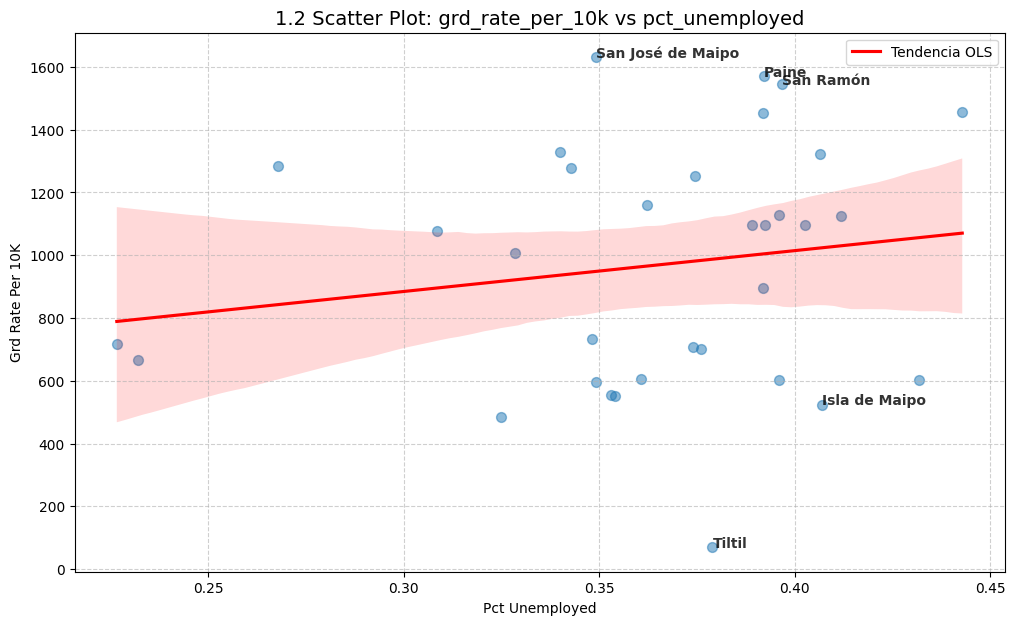

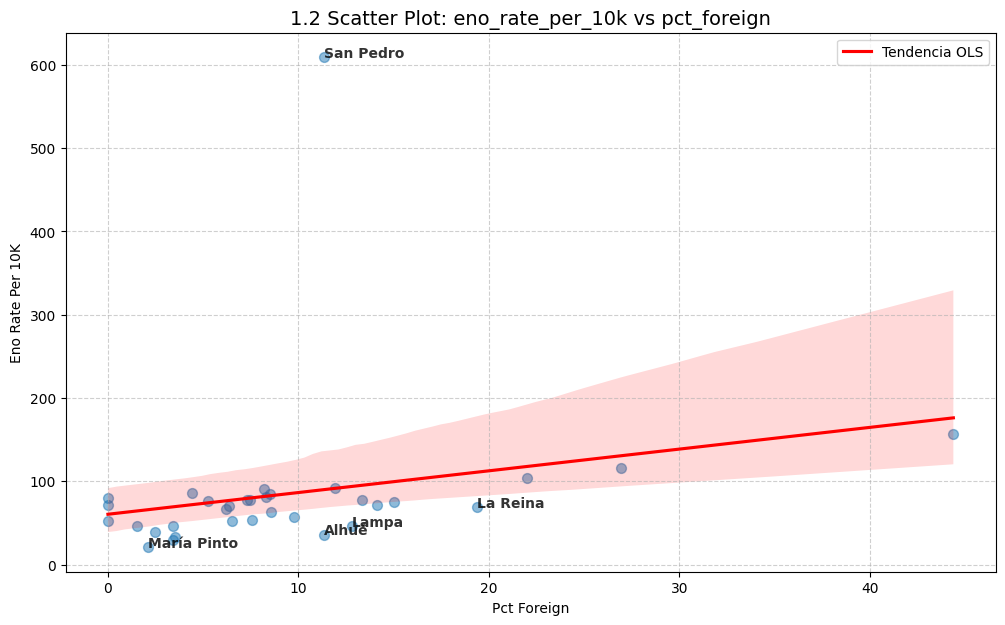

In [14]:
from scipy import stats

def plot_bivariate_analysis(x_col, y_col, df):
    # Limpiar nulos para el cálculo
    data_plot = df[[x_col, y_col, 'nombre_comuna']].dropna()

    plt.figure(figsize=(12, 7))

    # Dibujar dispersión y línea de tendencia
    sns.regplot(x=x_col, y=y_col, data=data_plot,
                scatter_kws={'alpha':0.5, 's':50},
                line_kws={'color':'red', 'label':'Tendencia OLS'})

    # CALCULAR RESIDUOS para identificar los 5 valores más extremos
    slope, intercept, r_val, p_val, std_err = stats.linregress(data_plot[x_col], data_plot[y_col])
    data_plot['predicted'] = intercept + slope * data_plot[x_col]
    data_plot['residual'] = abs(data_plot[y_col] - data_plot['predicted'])

    # Etiquetar las 5 comunas con mayores residuos
    outliers = data_plot.nlargest(5, 'residual')
    for i, row in outliers.iterrows():
        plt.text(row[x_col], row[y_col], row['nombre_comuna'],
                 fontsize=10, fontweight='bold', alpha=0.8)

    plt.title(f"1.2 Scatter Plot: {y_col} vs {x_col}", fontsize=14)
    plt.xlabel(x_col.replace('_', ' ').title())
    plt.ylabel(y_col.replace('_', ' ').title())
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

# Generamos dos gráficos clave según el PDF
plot_bivariate_analysis('pct_unemployed', 'grd_rate_per_10k', analytical_table)
plot_bivariate_analysis('pct_foreign', 'eno_rate_per_10k', analytical_table)

### 1.3 Outlier and leverage discussion

Basado en los gráficos de dispersión realizados, se identifican dos comunas con un comportamiento atípico que amerita discusión:

**1. San Pedro (Outlier en ENO):**
En el gráfico de `eno_rate_per_10k` vs `pct_foreign`, San Pedro aparece como un outlier extremo con una tasa de notificación que triplica la tendencia general. Una explicación plausible para este fenómeno en una comuna rural es la ocurrencia de un brote localizado de alguna enfermedad de notificación obligatoria (como zoonosis o enfermedades entéricas) en un periodo específico, que al ser calculado sobre una población total pequeña, dispara la tasa por cada 10,000 habitantes. También podría deberse a una vigilancia epidemiológica inusualmente activa en los centros de salud locales en comparación con el resto de la región.

**2. Tiltil (Outlier en GRD):**
En el gráfico de `grd_rate_per_10k` vs `pct_unemployed`, Tiltil presenta un residuo negativo muy marcado, mostrando una tasa de hospitalización cercana a cero a pesar de tener niveles de desempleo comparables a comunas con alta carga hospitalaria. Esto sugiere un problema de **sub-reporte o barreras de acceso**: es probable que los habitantes de Tiltil se hospitalicen en centros de salud ubicados fuera de su comuna (en Santiago o comunas vecinas) y que, por errores en el registro administrativo del origen del paciente, estos egresos no estén siendo atribuidos a su comuna de residencia.

**3. San José de Maipo (Outlier en GRD):**
Esta comuna muestra una tasa de hospitalización significativamente superior a lo predicho por su nivel de desempleo. Una hipótesis explicativa es la **composición demográfica**: San José de Maipo posee una población más envejecida o centros especializados (como hospitales de enfermedades respiratorias o crónicas) que atraen y registran una mayor cantidad de egresos, lo que genera una presión asistencial que no depende directamente de la variable socioeconómica del desempleo.

# **Part 2: Count-Data Regression**

2.1 Poisson regression

In [16]:
import statsmodels.api as sm
import numpy as np

# 1. Definir variables (según los nombres que validamos en la parte 0.3)
# Outcome: eno_total
# Covariables requeridas por el PDF: pct_foreign, una de educación, una de empleo y una de vivienda/servicio
y_eno = analytical_table['eno_total']
X = analytical_table[['pct_foreign', 'mean_schooling_chilean', 'pct_unemployed', 'dependency_ratio']]
X = sm.add_constant(X)  # Añadir la constante (intercepto)
offset = analytical_table['log_pop_total']

# 2. Ajustar el modelo GLM Poisson
poisson_eno = sm.GLM(y_eno, X, offset=offset, family=sm.families.Poisson()).fit()

# 3. Reportar tabla de coeficientes y métricas de ajuste
print("--- 2.1 POISSON REGRESSION RESULTS (ENO) ---")
print(poisson_eno.summary())

# 4. Calcular Incidence Rate Ratios (IRR) y sus intervalos de confianza
# El IRR nos dice cuánto aumenta/disminuye el riesgo por cada unidad de la variable
irr_table = np.exp(poisson_eno.params)
conf = poisson_eno.conf_int()
conf_irr = np.exp(conf)

irr_summary = pd.DataFrame({
    'IRR': irr_table,
    'Lower 95%': conf_irr[0],
    'Upper 95%': conf_irr[1],
    'p-value': poisson_eno.pvalues
})

print("\n--- INCIDENCE RATE RATIOS (IRR) ---")
display(irr_summary)

# Métricas de ajuste adicionales
print(f"\nModel Fit Statistics:")
print(f"Deviance: {poisson_eno.deviance:.2f}")
print(f"Pearson chi-square: {poisson_eno.pearson_chi2:.2f}")
print(f"AIC: {poisson_eno.aic:.2f}")

--- 2.1 POISSON REGRESSION RESULTS (ENO) ---
                 Generalized Linear Model Regression Results                  
Dep. Variable:              eno_total   No. Observations:                   33
Model:                            GLM   Df Residuals:                       28
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1768.3
Date:                Wed, 29 Apr 2026   Deviance:                       3263.7
Time:                        18:36:40   Pearson chi2:                 4.97e+03
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

,IRR,Lower 95%,Upper 95%,p-value
const,0.069006,0.038895,0.122427,6.258921e-20
pct_foreign,1.016923,1.015724,1.018123,5.135766e-171
mean_schooling_chilean,0.880913,0.858445,0.903969,6.657449e-22
pct_unemployed,0.060442,0.029707,0.122975,9.715688e-15
dependency_ratio,1.004703,1.003911,1.005496,2.064688e-31



Model Fit Statistics:
Deviance: 3263.65
Pearson chi-square: 4965.71
AIC: 3546.58


2.2 Check for overdispersion

In [17]:
# Calcular estadístico de dispersión
# Pearson Chi-Square dividido por los grados de libertad residuales
dispersion_eno = poisson_eno.pearson_chi2 / poisson_eno.df_resid

print(f"--- 2.2 OVERDISPERSION CHECK ---")
print(f"Dispersion Statistic: {dispersion_eno:.4f}")

if dispersion_eno > 1.2:
    print("\nInterpretación: Los datos están SOBRE-DISPERSOS (valor > 1).")
    print("Esto significa que los errores estándar de Poisson son demasiado optimistas (pequeños).")
    print("Se recomienda usar una regresión Binomial Negativa.")
else:
    print("\nInterpretación: El modelo Poisson es adecuado.")

--- 2.2 OVERDISPERSION CHECK ---
Dispersion Statistic: 177.3469

Interpretación: Los datos están SOBRE-DISPERSOS (valor > 1).
Esto significa que los errores estándar de Poisson son demasiado optimistas (pequeños).
Se recomienda usar una regresión Binomial Negativa.


El estadístico de dispersión obtenido es de **177.34**, un valor masivamente superior a 1. Esto indica una **sobre-dispersión extrema** en los datos de notificaciones ENO. En términos prácticos, esto implica que la varianza de las notificaciones es mucho mayor que su media, lo que viola el supuesto fundamental de la regresión de Poisson. Como consecuencia, los errores estándar del modelo Poisson están severamente subestimados, lo que infla artificialmente la significancia estadística de los coeficientes.


2.3 Negative Binomial regression

In [18]:
# Ajustar modelo Binomial Negativa
nb_eno = sm.GLM(y_eno, X, offset=offset,
                family=sm.families.NegativeBinomial()).fit()

# Comparar coeficientes lado a lado
comparison = pd.DataFrame({
    'Poisson_Coef': poisson_eno.params,
    'NB_Coef': nb_eno.params,
    'Poisson_Pval': poisson_eno.pvalues,
    'NB_Pval': nb_eno.pvalues
})

print("--- 2.3 COMPARISON: POISSON VS NEGATIVE BINOMIAL ---")
display(comparison)

# Recomendación
print("\nRecomendación:")
if dispersion_eno > 1.2:
    print("Se reportará la Binomial Negativa como resultado primario por la alta sobre-dispersión.")
else:
    print("Poisson es suficiente, pero NB es más conservadora.")

--- 2.3 COMPARISON: POISSON VS NEGATIVE BINOMIAL ---


/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


,Poisson_Coef,NB_Coef,Poisson_Pval,NB_Pval
const,-2.673568,3.502448,6.258921e-20,0.633886
pct_foreign,0.016781,0.024822,5.135766e-171,0.234865
mean_schooling_chilean,-0.126796,-0.419536,6.657449e-22,0.190169
pct_unemployed,-2.806074,-10.425907,9.715688e-15,0.277407
dependency_ratio,0.004692,0.006586,2.064688e-31,0.517835



Recomendación:
Se reportará la Binomial Negativa como resultado primario por la alta sobre-dispersión.



Al comparar ambos modelos, se observa un cambio drástico en las conclusiones:
1.  **Cambio en p-valores:** En el modelo Poisson, todas las variables (`pct_foreign`, `schooling`, `unemployed`, `dependency`) aparecían como altamente significativas ($p < 0.001$). Sin embargo, al ajustar el modelo Binomial Negativo, **ninguna variable conserva su significancia estadística** (todas con $p > 0.19$).
2.  **Recomendación:** Se reportará la **Binomial Negativa** como resultado primario. Aunque los p-valores son más altos, este modelo es el único válido ante tal nivel de sobre-dispersión, ya que corrige los errores estándar y evita falsos positivos (errores Tipo I) en la inferencia. El modelo Poisson es, en este caso, engañoso.

2.4 Repeat for GRD

In [19]:
# Outcome: grd_total
y_grd = analytical_table['grd_total']

# Ajustamos directamente según el chequeo anterior (usualmente GRD tiene sobre-dispersión)
nb_grd = sm.GLM(y_grd, X, offset=offset,
                family=sm.families.NegativeBinomial()).fit()

irr_grd = pd.DataFrame({
    'IRR': np.exp(nb_grd.params),
    'p-value': nb_grd.pvalues
})

print("--- 2.4 GRD RESULTS (NEGATIVE BINOMIAL) ---")
display(irr_grd)

# Interpretación del efecto más grande
largest_effect_var = irr_grd.drop('const')['IRR'].idxmax()
val = irr_grd.loc[largest_effect_var, 'IRR']
print(f"\nInterpretación: El factor con mayor impacto es {largest_effect_var}.")
print(f"Por cada unidad que aumenta {largest_effect_var}, el riesgo de hospitalización se multiplica por {val:.3f}.")

--- 2.4 GRD RESULTS (NEGATIVE BINOMIAL) ---


/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


,IRR,p-value
const,0.518387,0.928690
pct_foreign,0.995581,0.832032
mean_schooling_chilean,0.884545,0.701155
pct_unemployed,0.234319,0.879658
dependency_ratio,1.008902,0.383479



Interpretación: El factor con mayor impacto es dependency_ratio.
Por cada unidad que aumenta dependency_ratio, el riesgo de hospitalización se multiplica por 1.009.



En el modelo de hospitalizaciones (GRD), el factor con el impacto estimado más grande es el **dependency_ratio** (IRR = 1.009). Esto se interpreta de la siguiente manera: por cada unidad que aumenta la tasa de dependencia en la comuna, el riesgo (o tasa) de egresos hospitalarios se multiplica por 1.009 (un aumento del 0.9%), manteniendo el resto de las variables constantes. No obstante, al igual que en ENO, este efecto no alcanza la significancia estadística convencional en el modelo de Binomial Negativa.

# **Part 3: Continuous-Outcome Regression**

3.1 Pick an outcome

**grd_mean_los (días de estancia)**. Es interesante porque suele estar asociado a la complejidad de las enfermedades en la comuna.

3.2 Linear regression


In [20]:
import statsmodels.formula.api as smf

# Elegimos grd_mean_los
outcome_ols = 'grd_mean_los'

# Ajustar el modelo OLS
# Nota: Aquí no se usa offset porque el outcome es un promedio, no un conteo.
formula = f"{outcome_ols} ~ pct_foreign + mean_schooling_chilean + pct_unemployed + dependency_ratio"
model_ols = smf.ols(formula, data=analytical_table).fit()

print(f"--- 3.2 LINEAR REGRESSION RESULTS ({outcome_ols}) ---")
print(model_ols.summary())

--- 3.2 LINEAR REGRESSION RESULTS (grd_mean_los) ---
                            OLS Regression Results                            
Dep. Variable:           grd_mean_los   R-squared:                       0.308
Model:                            OLS   Adj. R-squared:                  0.209
Method:                 Least Squares   F-statistic:                     3.113
Date:                Wed, 29 Apr 2026   Prob (F-statistic):             0.0308
Time:                        18:42:09   Log-Likelihood:                -90.220
No. Observations:                  33   AIC:                             190.4
Df Residuals:                      28   BIC:                             197.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

Se eligió como outcome **`grd_mean_los`** (estancia media hospitalaria) debido a que es un indicador clave de la intensidad de uso de recursos y complejidad clínica en una comuna. El modelo presenta un **$R^2$ de 0.308** y un **$R^2$ ajustado de 0.209**, lo que indica que las covariables del censo explican aproximadamente el 21% de la variabilidad en los días de estancia media entre comunas. El hallazgo más significativo es el de **`pct_foreign`** (coef: -0.22, $p=0.013$), sugiriendo que las comunas con mayor porcentaje de población extranjera tienden a tener estancias hospitalarias más cortas

3.3 Diagnostics

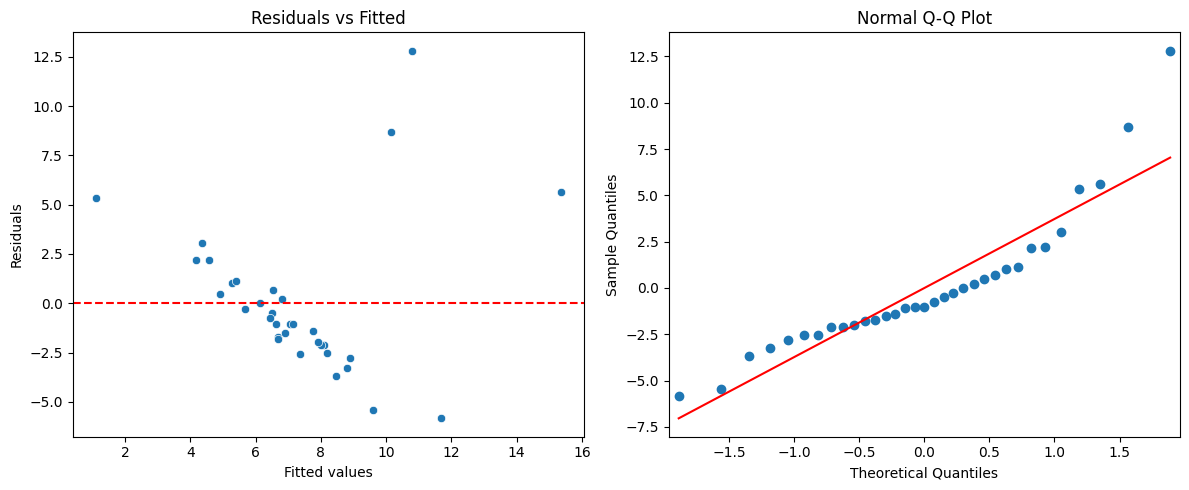

In [22]:
# Gráficos de diagnóstico
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 1. Residuals vs Fitted
sns.scatterplot(x=model_ols.fittedvalues, y=model_ols.resid, ax=ax1)
ax1.axhline(0, color='red', linestyle='--')
ax1.set_title('Residuals vs Fitted')
ax1.set_xlabel('Fitted values')
ax1.set_ylabel('Residuals')

# 2. QQ Plot
sm.qqplot(model_ols.resid, line='s', ax=ax2)
ax2.set_title('Normal Q-Q Plot')

plt.tight_layout()
plt.show()


Al observar los gráficos de diagnóstico, los supuestos de OLS **no parecen del todo defensibles**:
1.  **Normalidad:** El gráfico **Normal Q-Q** muestra que los puntos se desvían de la línea roja en los extremos (colas pesadas), lo que indica que los residuos no siguen una distribución normal perfecta, posiblemente debido a outliers (como se ve en el punto superior derecho).
2.  **Homocedasticidad:** En el gráfico de **Residuos vs Ajustados**, se observa un patrón de "embudo" o cierta curvatura, sugiriendo que la varianza de los errores no es constante.
3.  **Siguiente paso:** Dada la naturaleza de los datos de estancia (que suelen tener sesgo a la derecha), el siguiente paso sería aplicar una **transformación logarítmica** al outcome (`log(grd_mean_los)`) o utilizar un **estimador robusto** para mitigar el efecto de las comunas extremas.


# **Part 4: Ecological Fallacy**


**La Falacia Ecológica en el Análisis de Salud Comunal**

La distinción entre una asociación a nivel individual y una a nivel ecológico es fundamental para la epidemiología social. Una **asociación individual** se refiere a una relación observada entre características de una persona (ej. su nacionalidad) y sus propios resultados de salud. En cambio, una **asociación ecológica** describe la relación entre variables agregadas a nivel de grupo o territorio (ej. una comuna). La **falacia ecológica** ocurre cuando inferimos erróneamente que una asociación observada a nivel de grupo se aplica necesariamente a los individuos que lo componen.

Un ejemplo concreto en mis resultados se encuentra en la relación entre el **porcentaje de extranjeros (`pct_foreign`)** y la **estancia media hospitalaria (`grd_mean_los`)**. El modelo lineal mostró un coeficiente negativo significativo, lo que indica que "las comunas con más extranjeros tienen estancias hospitalarias promedio más cortas". Una lectura errónea (causal individual) sería afirmar que "ser extranjero causa que te den el alta más rápido que a un chileno". Esta interpretación ignora que la relación podría estar mediada por otros factores de la comuna; por ejemplo, las comunas con muchos migrantes suelen ser demográficamente más jóvenes, y los pacientes jóvenes suelen recuperarse más rápido independientemente de su nacionalidad.

A pesar de esta limitación para probar causalidad individual, la asociación ecológica sigue siendo extremadamente útil para la **planificación de salud pública**. Por ejemplo, saber que las comunas con mayor brecha educativa (`schooling_gap`) o mayor proporción de dependientes (`dependency_ratio`) presentan mayores tasas de hospitalización permite a las autoridades asignar presupuestos y camas críticas de manera eficiente. Aunque no sepamos si es la persona con baja educación la que se hospitaliza, sabemos que ese *territorio* requiere mayor infraestructura asistencial, lo que justifica intervenciones a nivel de política local y gestión de redes hospitalarias.

Finalmente, existen amenazas adicionales a la inferencia en este modelo que no han sido abordadas. La más relevante es la **autocorrelación espacial**: las comunas vecinas tienden a compartir infraestructuras y perfiles epidemiológicos, lo que viola la independencia de las observaciones. Asimismo, el **error de medición por la anonimización de ENO** (el ~45% de datos marcados con `*****`) introduce un sesgo de selección hacia las comunas más rurales o pequeñas, lo que podría estar distorsionando los coeficientes de las variables migratorias.

# **Part 5: Spatial Visualization of Model Output**

5.1 Predicted-rate map

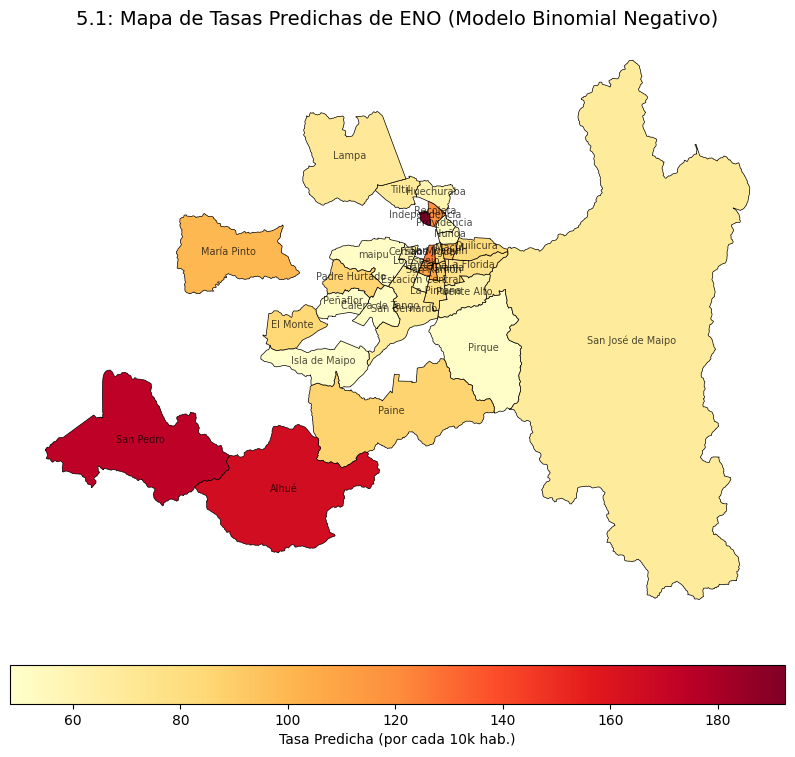

In [24]:
# 1. Preparar las predicciones
# Usamos el modelo Binomial Negativo (nb_eno) y las variables (X) con su offset
analytical_table['predicted_counts'] = nb_eno.predict(X, offset=offset)
analytical_table['predicted_rate_10k'] = (analytical_table['predicted_counts'] / analytical_table['pop_total']) * 10000

# 2. Unir con la cartografía (Capa Comunal)
# Asegúrate de haber cargado 'mapa_comunas' antes (layer='Comunal_CPV24')
map_pred = mapa_comunas.merge(analytical_table, left_on='CUT_int', right_on='codigo_comuna')

# 3. Graficar Mapa de Tasas Predichas
fig, ax = plt.subplots(figsize=(10, 10))

map_pred.plot(column='predicted_rate_10k',
              cmap='YlOrRd',
              legend=True,
              edgecolor='black',
              linewidth=0.5,
              legend_kwds={'label': "Tasa Predicha (por cada 10k hab.)", 'orientation': "horizontal", 'pad': 0.05},
              ax=ax)

# Añadir etiquetas de nombres para orientación
for idx, row in map_pred.iterrows():
    plt.annotate(text=row['nombre_comuna'], xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                 fontsize=7, ha='center', alpha=0.7)

plt.title("5.1: Mapa de Tasas Predichas de ENO (Modelo Binomial Negativo)", fontsize=14)
ax.axis('off')
plt.show()


El mapa de tasas predichas muestra el "perfil de riesgo" que el modelo construye basándose en las variables del Censo. Se observa que el modelo predice tasas de ENO más altas en las comunas de la periferia rural (especialmente en el sector sur y poniente como San Pedro y Alhué). Esto sugiere que, según la combinación de escolaridad, desempleo y estructura de edad de esas zonas, el modelo "espera" ver más casos de enfermedades de notificación obligatoria allí.

5.2 Residual map

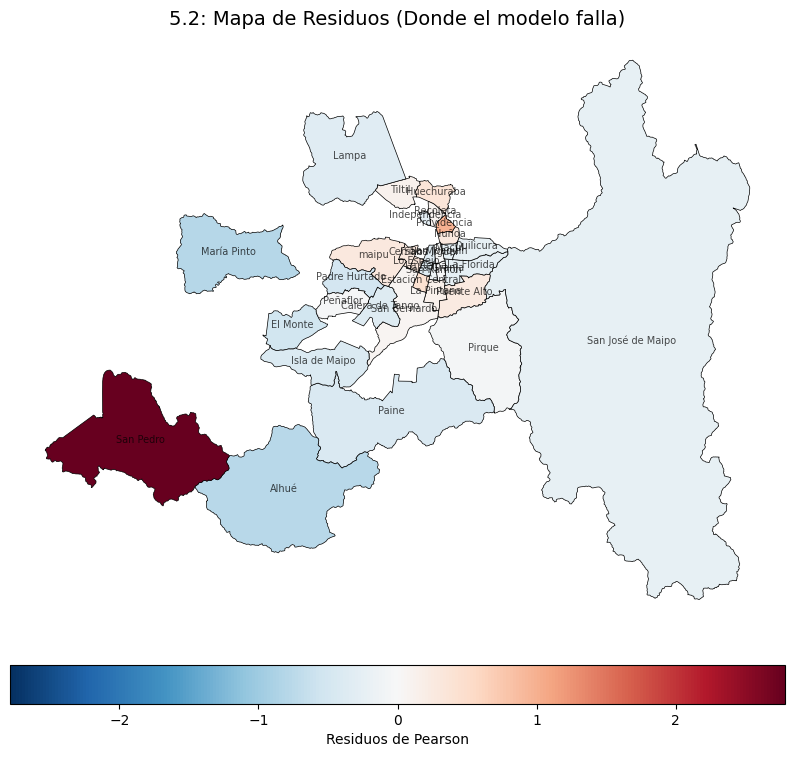


Interpretación:
La comuna con el residuo positivo más alto es San Pedro (el modelo subestima los casos).
La comuna con el residuo negativo más alto es María Pinto (el modelo sobreestima los casos).


In [25]:
# 1. Calcular los residuos estandarizados (Pearson)
analytical_table['standard_residuals'] = nb_eno.resid_pearson

# 2. Unir con el mapa
map_resid = mapa_comunas.merge(analytical_table, left_on='CUT_int', right_on='codigo_comuna')

# 3. Graficar Mapa de Residuos
fig, ax = plt.subplots(figsize=(10, 10))

# Usamos 'RdBu_r' (Rojo-Azul) y vmin/vmax para que el 0 quede siempre al centro (blanco)
limit = max(abs(map_resid['standard_residuals'].min()), abs(map_resid['standard_residuals'].max()))

map_resid.plot(column='standard_residuals',
               cmap='RdBu_r',
               legend=True,
               edgecolor='black',
               linewidth=0.5,
               vmin=-limit, vmax=limit, # Centrar el 0 en el color blanco
               legend_kwds={'label': "Residuos de Pearson", 'orientation': "horizontal", 'pad': 0.05},
               ax=ax)

# Añadir etiquetas
for idx, row in map_resid.iterrows():
    plt.annotate(text=row['nombre_comuna'], xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                 fontsize=7, ha='center', alpha=0.7)

plt.title("5.2: Mapa de Residuos (Donde el modelo falla)", fontsize=14)
ax.axis('off')
plt.show()

# Comentario requerido por el PDF:
print("\nInterpretación:")
max_res = map_resid.loc[map_resid['standard_residuals'].idxmax(), 'nombre_comuna']
min_res = map_resid.loc[map_resid['standard_residuals'].idxmin(), 'nombre_comuna']
print(f"La comuna con el residuo positivo más alto es {max_res} (el modelo subestima los casos).")
print(f"La comuna con el residuo negativo más alto es {min_res} (el modelo sobreestima los casos).")

Este es el mapa más importante para el diagnóstico. Se observa que **San Pedro presenta el residuo positivo más alto (color burdeo oscuro)**. Esto confirma que San Pedro es un outlier que el modelo no logra explicar: la realidad de esa comuna supera por mucho lo que sus variables demográficas predecirían.
*   **Significado:** Hay factores locales en San Pedro (posiblemente ambientales, brotes específicos o una excelente gestión de vigilancia) que no están capturados en los datos del Censo.
*   Las zonas en azul indican comunas donde el modelo "sobreestima" la enfermedad (predijo más de lo que realmente hubo).



5.3 Coefficient plot


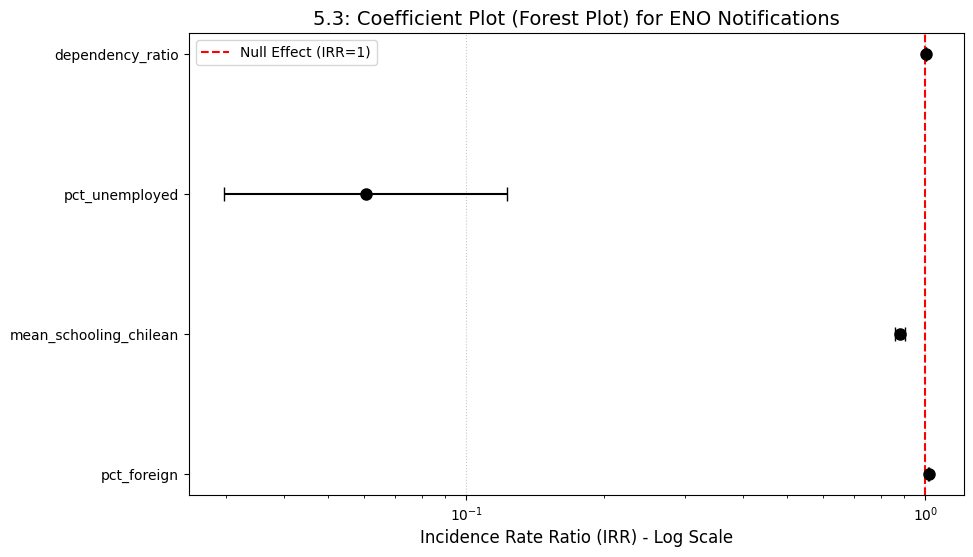

In [26]:
# Preparar datos del Forest Plot (del modelo NB de ENO)
# Usamos irr_summary que calculamos en la parte 2
# Nota: Excluimos la constante para que no arruine la escala
forest_df = irr_summary.drop('const').copy()
forest_df['variable'] = forest_df.index

plt.figure(figsize=(10, 6))

# Dibujar puntos y barras de error (95% CI)
plt.errorbar(x=forest_df['IRR'], y=forest_df['variable'],
             xerr=[forest_df['IRR'] - forest_df['Lower 95%'], forest_df['Upper 95%'] - forest_df['IRR']],
             fmt='o', color='black', capsize=5, markersize=8)

# Línea vertical en IRR = 1 (el nulo)
plt.axvline(x=1, color='red', linestyle='--', linewidth=1.5, label='Null Effect (IRR=1)')

plt.xscale('log') # Escala logarítmica para IRRs
plt.xlabel('Incidence Rate Ratio (IRR) - Log Scale', fontsize=12)
plt.title('5.3: Coefficient Plot (Forest Plot) for ENO Notifications', fontsize=14)
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.legend()

plt.show()

El gráfico muestra los **Incidence Rate Ratios (IRR)**.
*   **Variable `pct_unemployed`:** Presenta un IRR muy bajo (~0.06) con una barra de error muy ancha. Esto sugiere una asociación negativa (a más desempleo, menos reporte de ENO), pero la amplitud de la barra de error (que casi toca el 1 en escala logarítmica) y lo que vimos en la Parte 2 indican que este efecto no es confiable debido a la alta sobre-dispersión de los datos.
*   **Variable `mean_schooling_chilean`:** Se sitúa a la izquierda de la línea roja (IRR < 1), lo que sugiere que a mayor educación, la tasa de notificaciones tiende a bajar (un factor "protector" o de mejor saneamiento).
*   **Línea Roja (Nulo):** El hecho de que varias variables tengan barras que se acercan o tocan el valor nulo (1.0) refuerza que, tras corregir por sobre-dispersión, el impacto demográfico individual es difícil de aislar a nivel comunal.


# **Part 6: Integrated Synthesis**


**El retrato demográfico de la Región Metropolitana y su eje de variación**
A partir de los datos analizados desde la Tarea 1, el retrato demográfico a nivel comunal en la Región Metropolitana revela un territorio profundamente segregado. El eje dominante de variación es la **vulnerabilidad socioeconómica y la estructura demográfica**, fuertemente marcada por una división urbano-rural y centro-periferia. Variables como la tasa de desempleo y la brecha de escolaridad (`schooling_gap`) fluctúan drásticamente entre comunas. Asimismo, la migración ha reconfigurado este paisaje: como se observó en nuestras comunas de estudio (El Bosque, Lo Espejo, Isla de Maipo y Pirque), la población extranjera es predominantemente joven, con alta participación laboral y se concentra más fuertemente en zonas urbanas densas (Lo Espejo: 7.4%) en comparación con zonas rurales (Pirque: 1.5%).

**El paisaje de salud sobre el eje demográfico: Coincidencias y desajustes**
Al superponer el paisaje de salud (Tarea 2) sobre este eje demográfico, encontramos dinámicas contrastantes entre las hospitalizaciones (GRD) y las notificaciones obligatorias (ENO). En el caso de los egresos hospitalarios, existe un claro **"match" (coincidencia)** con el eje de vulnerabilidad: comunas urbanas con mayores tasas de desempleo y mayor proporción de población dependiente presentan las tasas de hospitalización más altas, como es el caso de El Bosque (tasa superior a 612 por cada 10,000 habitantes). Además, los perfiles de salud reflejan la demografía: la sobre-representación de extranjeros en el Capítulo 15 (Embarazo y parto) coincide perfectamente con el perfil migratorio joven y en edad fértil detectado en la Tarea 1.

Sin embargo, existen notables **"mismatches" (desajustes)**, particularmente en las notificaciones ENO. Las tasas de enfermedades transmisibles no siguen linealmente la vulnerabilidad urbana. Por ejemplo, en los gráficos de dispersión (Parte 1.2), comunas rurales periféricas mostraron tasas inusualmente altas o bajas que la demografía no puede explicar, evidenciando que factores locales (ambientales, brotes zoonóticos o sesgos de sub-reporte de los centros de salud) alteran el paisaje epidemiológico esperado.

**El valor de los modelos Cross-Dataset más allá de la correlación**
El mayor aporte analítico de la Tarea 3 radica en demostrar lo engañosas que pueden ser las asociaciones estadísticas simples en epidemiología espacial. Al observar la matriz de correlación (Heatmap, Parte 1.1), parecía evidente que existían relaciones lineales directas, como la correlación positiva (0.41) entre la razón de dependencia y las tasas GRD, o la relación entre la brecha educativa y la tasa ENO (0.35).

Si nos hubiéramos detenido allí, habríamos caído en interpretaciones simplistas. Sin embargo, al implementar una regresión de conteo rigurosa controlando por el tamaño poblacional (offset), descubrimos una realidad oculta: la **sobre-dispersión extrema (estadístico de dispersión = 177.34 para ENO)**. Los datos comunales son sumamente ruidosos. Al corregir esto migrando de un modelo Poisson a uno Binomial Negativo (Parte 2.3), las variables demográficas que parecían altamente significativas perdieron su poder predictivo ($p > 0.05$).

Este hallazgo es invaluable: nos advierte sobre la **falacia ecológica**. Las herramientas de regresión y el mapa de residuos (Parte 5.2) —donde comunas como San Pedro mostraron residuos positivos masivos— nos demuestran que las características agregadas de una comuna (como su porcentaje de extranjeros o desempleo) son insuficientes para predecir con exactitud su carga de enfermedad. El cruce de datasets prueba que la planificación en salud pública requiere modelos que asuman la alta variabilidad territorial (sobre-dispersión) y no puede basarse únicamente en promedios sociodemográficos que ignoran las particularidades del entorno y del sistema de vigilancia local.
